In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [293]:
master_df = pd.read_csv('Team_Stats_Merge_2018_2025.csv')

In [294]:
master_df.info

<bound method DataFrame.info of      season                  team  tp_W  tp_L  tp_T  tp_W-L%  tp_PF  tp_PA  \
0      2018  New England Patriots    11     5   0.0    0.688    436    325   
1      2018        Miami Dolphins     7     9   0.0    0.438    319    433   
2      2018         Buffalo Bills     6    10   0.0    0.375    269    374   
3      2018         New York Jets     4    12   0.0    0.250    333    441   
4      2018      Baltimore Ravens    10     6   0.0    0.625    389    287   
..      ...                   ...   ...   ...   ...      ...    ...    ...   
251    2025    New Orleans Saints     6    11   0.0    0.353    306    383   
252    2025      Seattle Seahawks    14     3   0.0    0.824    483    292   
253    2025      Los Angeles Rams    12     5   0.0    0.706    518    346   
254    2025   San Francisco 49ers    12     5   0.0    0.706    437    371   
255    2025     Arizona Cardinals     3    14   0.0    0.176    355    488   

     tp_PD  tp_MoV  ...  def_ad

In [295]:
corr_matrix = master_df.corr(numeric_only=True)

In [296]:


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column].abs() > 0.85)
]

print(high_corr)

['tp_L', 'tp_W-L%', 'tp_PD', 'tp_MoV', 'tp_SRS', 'tp_OSRS', 'tp_DSRS', 'off_pts', 'off_yds', 'off_yds_per_play', 'off_penalty_yds', 'off_score_pct', 'off_turnover_pct', 'off_exp', 'def_g', 'def_pa', 'def_yds_per_play', 'def_score_pct', 'def_turnover_pct', 'def_exp', 'off_pass_G', 'off_pass_Att', 'off_pass_TD%', 'off_pass_Int', 'off_pass_Int%', 'off_pass_Y/A', 'off_pass_AY/A', 'off_pass_Y/G', 'off_pass_Rate', 'off_pass_Yds.1', 'off_pass_Sk%', 'off_pass_NY/A', 'off_pass_ANY/A', 'off_pass_EXP', 'off_rush_G', 'off_rush_Yds', 'off_rush_Y/G', 'def_pass_G', 'def_pass_Att', 'def_pass_TD%', 'def_pass_Int', 'def_pass_Int%', 'def_pass_Y/A', 'def_pass_AY/A', 'def_pass_Y/G', 'def_pass_Rate', 'def_pass_Yds.1', 'def_pass_Sk%', 'def_pass_NY/A', 'def_pass_ANY/A', 'def_pass_EXP', 'def_rush_G', 'def_rush_Y/G', 'def_adv_G', 'def_adv_Att', 'def_adv_Cmp', 'def_adv_Yds', 'def_adv_TD', 'def_adv_Sk', 'def_adv_Bltz%', 'def_adv_Hrry%', 'def_adv_QBKD%', 'def_adv_Prss%']


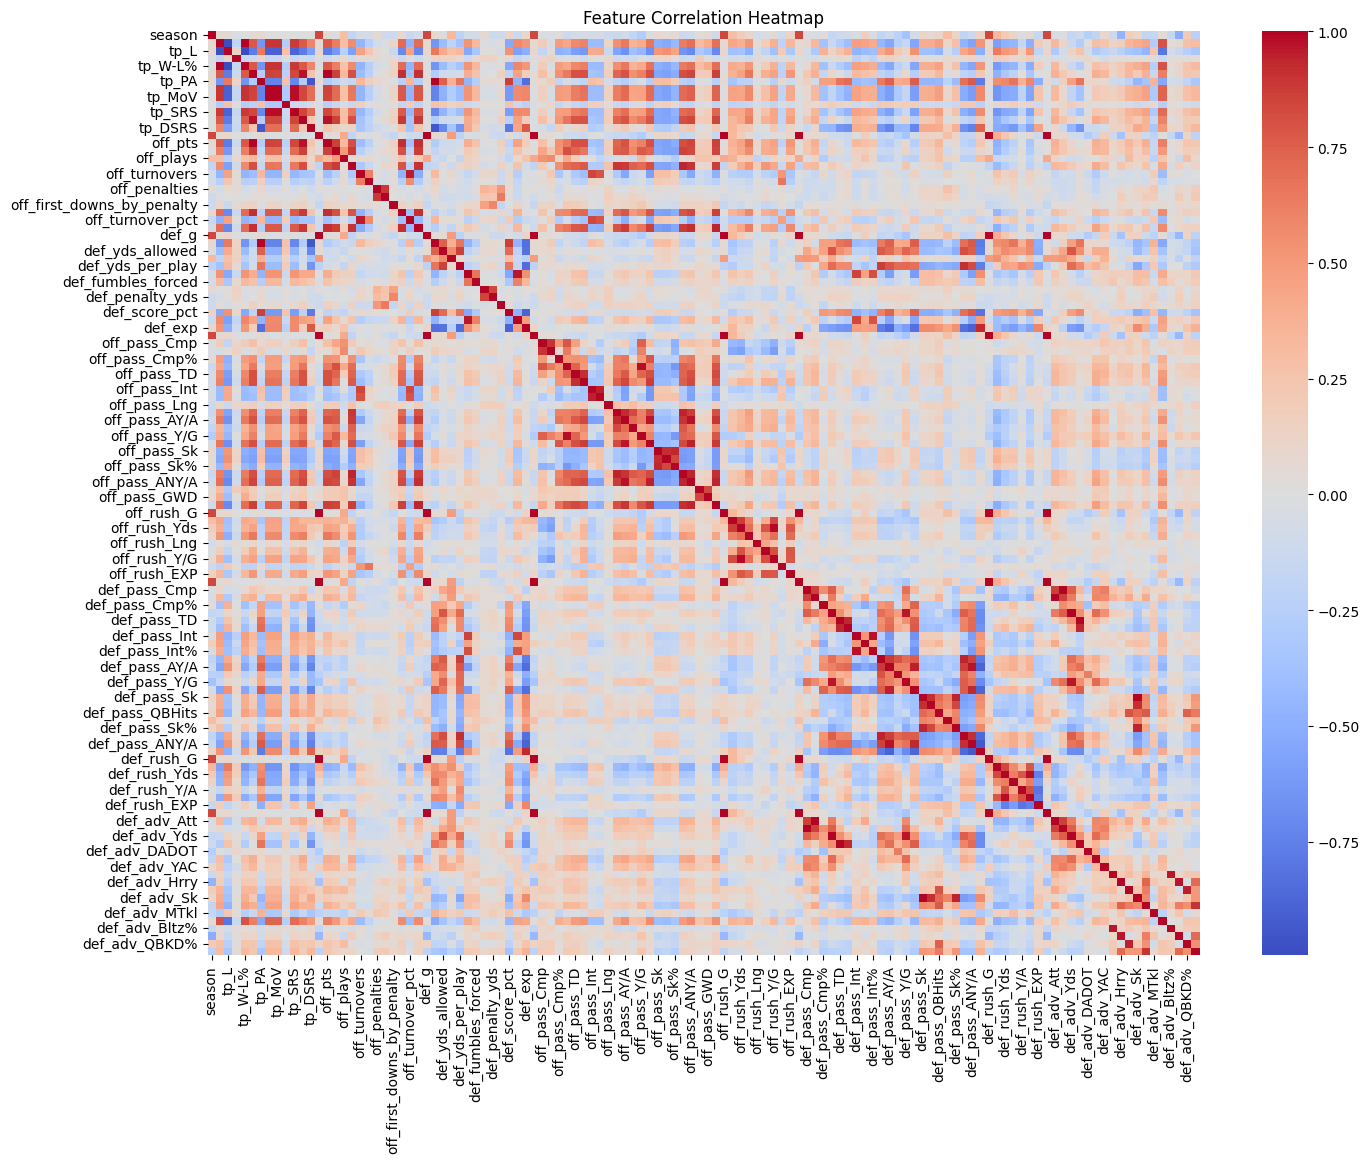

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))
sns.heatmap(master_df.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.title("Feature Correlation Heatmap")
plt.show()

## Test All Feautres

In [298]:
# Drop non-feature columns
drop_cols = ["season", "team", "made_playoffs"]  # adjust if needed

X = master_df.drop(columns=drop_cols)
y = master_df["made_playoffs"]

In [299]:
X.info

<bound method DataFrame.info of      tp_W  tp_L  tp_T  tp_W-L%  tp_PF  tp_PA  tp_PD  tp_MoV  tp_SoS  tp_SRS  \
0      11     5   0.0    0.688    436    325    111     6.9    -1.8     5.2   
1       7     9   0.0    0.438    319    433   -114    -7.1    -1.7    -8.8   
2       6    10   0.0    0.375    269    374   -105    -6.6    -0.3    -6.9   
3       4    12   0.0    0.250    333    441   -108    -6.8    -1.1    -7.8   
4      10     6   0.0    0.625    389    287    102     6.4     0.6     7.0   
..    ...   ...   ...      ...    ...    ...    ...     ...     ...     ...   
251     6    11   0.0    0.353    306    383    -77    -4.5    -0.3    -4.9   
252    14     3   0.0    0.824    483    292    191    11.2     1.6    12.8   
253    12     5   0.0    0.706    518    346    172    10.1     2.4    12.5   
254    12     5   0.0    0.706    437    371     66     3.9     2.1     6.0   
255     3    14   0.0    0.176    355    488   -133    -7.8     3.4    -4.4   

     ...  def_adv_B

## Handle difference in inconsistent rates vs totals

We will add a 
* feature for fumble rate to be consistent with Int rate : off_Fmb% = off_fumbles/ off_plays * 100
* feature for fumble rate to be consistent with Int rate : off_rush_TD% = off_rush_TD / off_rush_Att * 100


In [300]:
X['off_Fmb%'] = X['off_fumbles']/X['off_plays']
X['def_Fmb%'] = X['def_fumbles_forced']/X['def_plays']
X['def_adv_pass_TD%'] = X['def_adv_TD']/X['def_adv_Att']
X['off_rush_TD%'] = X['off_rush_TD']/X['off_rush_Att']
X['def_rush_TD%'] = X['def_rush_TD']/X['def_rush_Att']

/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_42971/3555649925.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['off_Fmb%'] = X['off_fumbles']/X['off_plays']
/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_42971/3555649925.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['def_Fmb%'] = X['def_fumbles_forced']/X['def_plays']
/var/folders/h0/js29tcr57_72tymq_lnnpnb80000gn/T/ipykernel_42971/3555649925.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [301]:
X.columns.tolist()

['tp_W',
 'tp_L',
 'tp_T',
 'tp_W-L%',
 'tp_PF',
 'tp_PA',
 'tp_PD',
 'tp_MoV',
 'tp_SoS',
 'tp_SRS',
 'tp_OSRS',
 'tp_DSRS',
 'off_g',
 'off_pts',
 'off_yds',
 'off_plays',
 'off_yds_per_play',
 'off_turnovers',
 'off_fumbles',
 'off_penalties',
 'off_penalty_yds',
 'off_first_downs_by_penalty',
 'off_score_pct',
 'off_turnover_pct',
 'off_exp',
 'def_g',
 'def_pa',
 'def_yds_allowed',
 'def_plays',
 'def_yds_per_play',
 'def_turnovers_forced',
 'def_fumbles_forced',
 'def_penalties',
 'def_penalty_yds',
 'def_first_downs_by_penalty',
 'def_score_pct',
 'def_turnover_pct',
 'def_exp',
 'off_pass_G',
 'off_pass_Cmp',
 'off_pass_Att',
 'off_pass_Cmp%',
 'off_pass_Yds',
 'off_pass_TD',
 'off_pass_TD%',
 'off_pass_Int',
 'off_pass_Int%',
 'off_pass_Lng',
 'off_pass_Y/A',
 'off_pass_AY/A',
 'off_pass_Y/C',
 'off_pass_Y/G',
 'off_pass_Rate',
 'off_pass_Sk',
 'off_pass_Yds.1',
 'off_pass_Sk%',
 'off_pass_NY/A',
 'off_pass_ANY/A',
 'off_pass_4QC',
 'off_pass_GWD',
 'off_pass_EXP',
 'off_rush_

In [302]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [303]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(25)

,feature,importance
3,tp_W-L%,0.133301
1,tp_L,0.120651
0,tp_W,0.100898
7,tp_MoV,0.056031
6,tp_PD,0.053898
9,tp_SRS,0.038649
4,tp_PF,0.034654
10,tp_OSRS,0.022138
13,off_pts,0.021613
5,tp_PA,0.017350


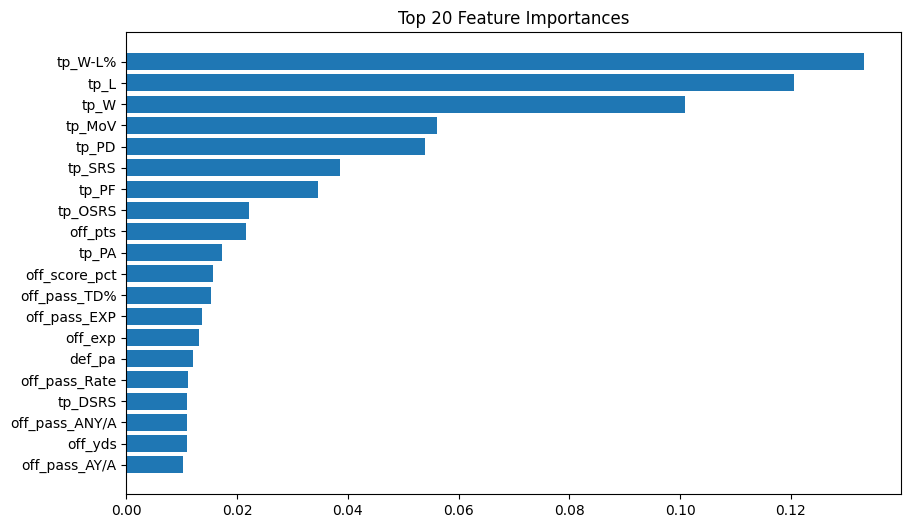

In [304]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

## Eliminate trival/nonrelevant features

Features that are obvious and should be remove because of noise.

Example:
Wins and scoring Points = playoffs 
Losses and giving up points != playoffs
Easier Schedule = playoffs

In [305]:
trivial_features = ['tp_W-L%',
                    'tp_W',
                    'tp_L',
                    'tp_PD',
                    'tp_MoV',
                    'tp_PF',
                    'tp_PA',
                    'tp_T',
                    'off_pts',
                    'def_pa',
                    'tp_SoS',
                    ]

## Eliminate aggregated / calculated features

These are features that will highly correlated and do not give signifcant interpretablebilty

Examples
* Anything with EXP/SRS (expect points and rating system) - not insightful - better teams get better ratings
* Total off/def yards - more interested in seeing passing and rushing splits not the total - 
* Total Efficiencies - more interested in seeing passing and rushing splits not the total - rush/pass Y/A instead of yds per play
* Efficieny > Volume - more interested in Yards/Attempt than Yards/Game
* Passing - Yards/Attempt > Yards/Completion - represents a better efficiency of yards gained per pass attempted rather than just the completed ones
* Rushing and Passing Attempt numbers as a whole falls under totals for me. After efficiency


In [306]:
aggregated_features = ['def_exp',
                       'off_exp',
                       'off_rush_exp',
                       'tp_SRS',
                        'tp_OSRS',
                        'tp_DSRS',
                       'off_yds',
                       'def_yds_allowed',
                       'def_pass_AY/A',
                       'off_pass_AY/A',
                       'off_pass_ANY/A',
                       'def_pass_ANY/A',
                       'off_rush_EXP',
                       'def_rush_EXP',
                        'off_pass_EXP',
                        'def_pass_EXP',
                        'off_yds_per_play',
                        'def_yds_per_play',
                        'off_rush_G',
                        'def_rush_G',
                        'def_adv_G',
                        'off_pass_G',
                        'def_pass_G',
                        'off_g',
                        'def_g',
                        'off_pass_Yds',
                        'def_rush_Yds',
                        'off_rush_Yds',
                        'def_pass_Yds',
                        'off_pass_Y/G',
                        'off_pass_Y/C',
                        'def_rush_Y/G',
                        'off_pass_TD',
                        'def_rush_Att',
                        'off_rush_Att',
                        'off_rush_Y/G',
                        'off_pass_Yds.1',
                        'def_pass_Yds.1',
                        'def_plays',
                        'off_plays',
                        'off_score_pct',
                        'def_score_pct',
                        'off_turnover_pct',
                        'def_turnover_pct',
                        'off_rush_Fmb',
                        'def_pass_Int',
                        'def_fumbles_forced',
                        'off_pass_Lng',
                        'off_turnovers',
                        'def_turnovers_forced',
                        'off_rush_TD',
                        'def_pass_Y/C',
                        'off_pass_Rate',
                        'def_pass_Rate',
                        'off_pass_Sk',
                        'def_pass_Sk',
                        'off_pass_Cmp',
                        'def_pass_Att',
                        'def_adv_Att',
                        'off_pass_Int',
                        'off_fumbles',
                        'off_pass_Int',
                        'def_rush_TD',
                        'off_rush_Lng',
                        'def_adv_Cmp',
                        'def_pass_Cmp',
                        'def_pass_TD',
                        'def_adv_Yds',
                        'def_pass_Y/G',
                        'def_adv_Bltz',
                        'def_pass_QBHits',
                        'off_pass_Att',
                        'def_adv_Sk',
                        'def_pass_Sk%',
                        'def_adv_Hrry',
                        'def_adv_Prss',
                        'def_adv_TD',
                        'off_pass_NY/A',
                        'def_pass_NY/A',
                        'def_adv_pass_TD%',
                        'def_adv_QBKD'
                        
                       ]

## Eliminate Situation Features

These are features that are too niche to the situation of the game. 

Examples
* Penalties - too random and obviously negative
* Game Winning Drives (GWD) - power house teams may not ever be in situation of GWD
* 4th Quarter Comback (4QC) - same as GWD


In [307]:
situational_features = ['off_penalties',
                        'def_penalties',
                        'def_penalty_yds',
                        'off_penalty_yds',
                        'off_pass_4QC',
                        'def_first_downs_by_penalty',
                        'off_first_downs_by_penalty',
                        'off_pass_GWD',
                        'off_fumbles',
                        
                        ]

In [308]:
'''
trivial_features = ['tp_W-L%',
                    'tp_L',
                    'tp_W',
                    'tp_PD',
                    'tp_SRS',
                    'tp_OSRS',
                    'tp_DSRS',
                    'off_pts',
                    'def_pa',
                    'tp_MoV',
                    'def_pass_AY/A',
                    'off_pass_AY/A',
                    'off_pass_NY/A',
                    'def_pass_NY/A',
                    'def_pass_Y/A',
                    'off_pass_Y/A',
                    'tp_PF',
                    'tp_PA',
                    'def_exp',
                    'off_exp',
                    'off_rush_exp',
                    'off_yds',
                    'def_yds_allowed',
                    'off_turnovers',
                    'def_turnovers_forced',
                    'off_pass_Yds',
                    'def_rush_Yds',
                    'off_rush_Yds',
                    'def_pass_Yds',
                    'off_pass_TD',
                    'off_pass_Y/G',
                    'def_rush_Y/G',
                    'off_pass_Cmp%',
                    'def_rush_Att',
                    'off_rush_Att',
                    'off_rush_Y/G',
                    'def_pass_PD',
                    'off_pass_Int',
                    'def_pass_Int',
                    'off_pass_Yds.1',
                    'def_pass_Yds.1',
                    'off_pass_Sk',
                    'off_pass_Sk%',
                    'def_pass_Sk%',
                    'def_pass_Sk',
                    'off_pass_GWD',
                    'def_plays',
                    'off_plays',
                    'def_pass_Att',
                    'def_rush_TD',
                    'off_rush_TD',
                    'off_pass_Y/C',
                    'def_pass_Cmp%',
                    'off_rush_Lng',
                    'off_pass_Att',
                    'def_adv_Att',
                    'def_pass_TD',
                    'def_pass_Y/C',
                    'off_pass_Y/G',
                    'off_rush_fumbles',
                    'def_pass_Y/G',
                    'off_pass_Cmp',
                    'tp_SoS',
                    'def_pass_TFL',
                    'off_pass_Lng',
                    'def_adv_Yds',
                    'def_pass_TD%',
                    'def_adv_Sk',
                    'def_adv_Cmp',
                    'def_penalties',
                    'def_penalty_yds',
                    'off_penalty_yds',
                    'def_pass_Cmp',
                    'off_penalties',
                    'def_adv_TD',
                    'off_pass_4QC',
                    'def_first_downs_by_penalty',
                    'off_first_downs_by_penalty',
                    'tp_T',
                    'off_pass_G',
                    'def_pass_G',
                    'off_g',
                    'def_g',
                    'off_rush_Fmb',
                    'off_rush_G',
                    'def_rush_G',
                    'def_adv_G',
                    'off_rush_EXP',
                    'def_rush_EXP',
                    'off_pass_EXP',
                    'def_pass_EXP',
                    'off_yds_per_play',
                    'def_yds_per_play',
                    'def_pass_Int%', 'def_adv_Bltz%', 'def_adv_Hrry%', 'def_adv_QBKD%', 'def_adv_Prss%'
                    ]
'''

"\ntrivial_features = ['tp_W-L%',\n                    'tp_L',\n                    'tp_W',\n                    'tp_PD',\n                    'tp_SRS',\n                    'tp_OSRS',\n                    'tp_DSRS',\n                    'off_pts',\n                    'def_pa',\n                    'tp_MoV',\n                    'def_pass_AY/A',\n                    'off_pass_AY/A',\n                    'off_pass_NY/A',\n                    'def_pass_NY/A',\n                    'def_pass_Y/A',\n                    'off_pass_Y/A',\n                    'tp_PF',\n                    'tp_PA',\n                    'def_exp',\n                    'off_exp',\n                    'off_rush_exp',\n                    'off_yds',\n                    'def_yds_allowed',\n                    'off_turnovers',\n                    'def_turnovers_forced',\n                    'off_pass_Yds',\n                    'def_rush_Yds',\n                    'off_rush_Yds',\n                    'def_pass_Yds',

In [309]:
X = X.drop(columns=trivial_features, errors='ignore')
X = X.drop(columns=aggregated_features, errors='ignore')
X = X.drop(columns=situational_features, errors='ignore')

In [310]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Simple split (this is fine for feature importance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [311]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance


,feature,importance
1,off_pass_TD%,0.119945
3,off_pass_Y/A,0.090912
10,def_pass_Y/A,0.057271
9,def_pass_Int%,0.054724
0,off_pass_Cmp%,0.053306
6,def_pass_Cmp%,0.052866
8,def_pass_PD,0.047286
7,def_pass_TD%,0.046703
4,off_pass_Sk%,0.046036
14,def_adv_Air,0.043182


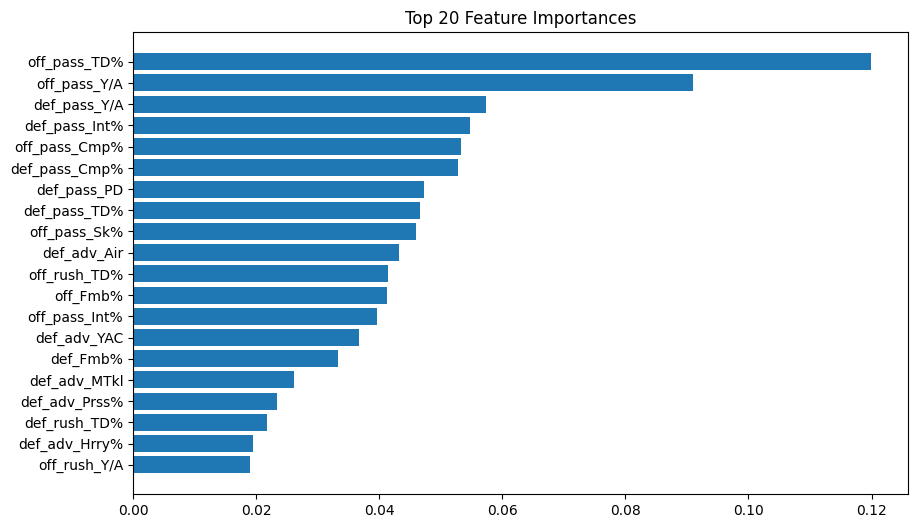

In [312]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

In [313]:
X


,off_pass_Cmp%,off_pass_TD%,off_pass_Int%,off_pass_Y/A,off_pass_Sk%,off_rush_Y/A,def_pass_Cmp%,def_pass_TD%,def_pass_PD,def_pass_Int%,...,def_adv_YAC,def_adv_MTkl,def_adv_Bltz%,def_adv_Hrry%,def_adv_QBKD%,def_adv_Prss%,off_Fmb%,def_Fmb%,off_rush_TD%,def_rush_TD%
0,65.9,5.1,1.9,7.7,3.5,4.3,61.2,4.8,67,3.0,...,2075,73,0.309,0.107,0.088,0.232,0.006524,0.009980,0.037657,0.019074
1,64.2,5.7,2.9,7.3,10.3,4.7,65.9,6.1,59,4.1,...,1905,119,0.258,0.140,0.071,0.258,0.011390,0.006836,0.018868,0.035052
2,54.3,2.6,4.6,6.2,7.6,4.2,63.6,4.5,73,3.3,...,1482,137,0.234,0.139,0.083,0.280,0.008929,0.011364,0.032051,0.038636
3,57.1,3.4,3.6,6.5,6.6,4.0,63.1,5.0,76,2.2,...,1879,115,0.314,0.096,0.093,0.241,0.011329,0.006598,0.026829,0.036364
4,60.1,3.2,1.6,6.7,5.4,4.5,58.4,3.6,89,2.1,...,1684,105,0.396,0.148,0.081,0.289,0.009692,0.005133,0.034735,0.031073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,67.2,3.2,2.0,6.8,7.7,3.7,63.5,5.1,79,2.0,...,1605,94,0.225,0.109,0.069,0.247,0.011163,0.009497,0.020690,0.023211
252,67.6,5.2,3.1,8.4,5.3,4.1,62.5,3.3,96,3.0,...,2060,110,0.193,0.106,0.100,0.261,0.012808,0.006573,0.037475,0.021531
253,64.9,7.7,1.3,7.9,3.7,4.6,64.0,4.4,82,2.7,...,1947,82,0.177,0.092,0.112,0.263,0.006446,0.009328,0.036559,0.018349
254,69.3,5.7,2.8,7.5,4.5,3.8,68.2,5.0,56,1.0,...,1939,88,0.183,0.076,0.065,0.167,0.005545,0.009728,0.031185,0.030660


In [314]:
print("Shape:", X.shape)
print("Any NaN?", X.isna().sum().sum())
print("Any inf?", np.isinf(X).sum().sum())

Shape: (256, 25)
Any NaN? 1
Any inf? 0


In [315]:
print(X.isna().sum()[X.isna().sum() > 0])

def_pass_Int%    1
dtype: int64


In [316]:
mask = X["def_pass_Int%"].isna()

print(master_df.loc[mask, ["season", "team", "def_pass_Att", "def_pass_Int"]])

     season           team  def_pass_Att  def_pass_Int
227    2025  New York Jets           515           NaN


In [317]:
X["def_pass_Int%"] = X["def_pass_Int%"].fillna(0)

In [318]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif.sort_values("VIF", ascending=False)
print(vif)

          Feature         VIF
6   def_pass_Cmp%  863.610071
20  def_adv_Prss%  784.671790
10   def_pass_Y/A  689.862849
0   off_pass_Cmp%  646.153614
3    off_pass_Y/A  375.116370
13  def_adv_DADOT  295.510438
5    off_rush_Y/A  187.503308
12   def_rush_Y/A  184.589347
18  def_adv_Hrry%  159.147091
14    def_adv_Air  143.696644
15    def_adv_YAC  116.082374
19  def_adv_QBKD%  115.983223
11   def_pass_TFL   72.680746
8     def_pass_PD   68.092390
1    off_pass_TD%   48.578972
7    def_pass_TD%   48.051730
16   def_adv_MTkl   36.204102
24   def_rush_TD%   28.048763
23   off_rush_TD%   28.017413
4    off_pass_Sk%   19.218739
17  def_adv_Bltz%   17.217087
9   def_pass_Int%   15.760731
2   off_pass_Int%   15.450138
22       def_Fmb%   12.930336
21       off_Fmb%   12.036601


### After Running the VIF eliminate extreme values

In [319]:
VIF_features = ['off_pass_Cmp%',
                'def_pass_Cmp%'
                ]

In [320]:
X = X.drop(columns=VIF_features, errors='ignore')
y = master_df["made_playoffs"]

In [321]:
model_df.to_csv("team_stats_model_ready.csv", index=False)

In [322]:
base_features = [
    # Passing efficiency (core drivers)
    "off_pass_Y/A",
    "off_pass_TD%",
    "off_pass_Int%",
    
    "def_pass_Y/A",
    "def_pass_TD%",
    "def_pass_Int%",
    
    # Rushing efficiency
    "off_rush_Y/A",
    "def_rush_Y/A",
    
    # Scoring efficiency (optional but useful)
    "off_rush_TD%",
    "def_rush_TD%",
    
    # Turnovers
    "off_Fmb%",
    "def_Fmb%",
    
    # Pass protection / disruption (offense side)
    "off_pass_Sk%",
    
    # One pressure metric placeholder (we will swap this)
    "def_adv_DADOT",
    "def_adv_Air",
    "def_adv_YAC"
    # DO NOT include here yet
]

pressure_features = [
    "def_adv_Prss%",
    "def_adv_Hrry%",
    "def_adv_QBKD%",
]

In [323]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

results = []

for feat in pressure_features:
    features = base_features + [feat]
    
    X_temp = X[features].copy()
    y = master_df["made_playoffs"]
    
    X_temp = X_temp.fillna(X_temp.median(numeric_only=True))
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y, test_size=0.2, random_state=42
    )
    
    model = RandomForestClassifier(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    
    results.append({
        "pressure_feature": feat,
        "accuracy": acc
    })

import pandas as pd
results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print(results_df)

  pressure_feature  accuracy
1    def_adv_Hrry%  0.807692
2    def_adv_QBKD%  0.769231
0    def_adv_Prss%  0.750000


Keep def_adv_Hrry%

In [325]:
import itertools
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# features you always want in the model
fixed_features = [
    "off_pass_Sk%",
    "def_pass_TFL",
]

# grouped alternatives: choose ONE from each group
feature_groups = {
    "off_pass_eff": ["off_pass_Y/A", "off_pass_TD%"],
    "def_pass_eff": ["def_pass_Y/A", "def_pass_PD", "def_pass_TD%"],
    "off_rush_score": ["off_rush_TD%","off_rush_Y/A"],
    "def_rush_score": ["def_rush_TD%","def_rush_Y/A"],
    "pressure": ["def_adv_Hrry%","def_adv_QBKD%","def_adv_Prss%","def_adv_Bltz%"],
    "def_turnover_eff": ["def_Fmb%","def_pass_Int%"],
    "off_turnover_eff": ["off_Fmb%","off_pass_Int%"]
    # add more groups if you want
}

results = []

group_names = list(feature_groups.keys())
group_options = [feature_groups[name] for name in group_names]

for combo in itertools.product(*group_options):
    selected_features = fixed_features + list(combo)

    X_temp = X[selected_features].copy()
    y = master_df["made_playoffs"].copy()

    # keep numeric only just in case
    X_temp = X_temp.select_dtypes(include=["number"]).copy()

    # handle missing values
    X_temp = X_temp.fillna(X_temp.median(numeric_only=True))

    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y, test_size=0.2, random_state=42
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    row = {
        "features": selected_features,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    # save which option was chosen from each group
    for name, feat in zip(group_names, combo):
        row[name] = feat

    results.append(row)

results_df = pd.DataFrame(results).sort_values(
    ["accuracy", "f1"], ascending=False
)

results_df.head(10)

,features,accuracy,f1,off_pass_eff,def_pass_eff,off_rush_score,def_rush_score,pressure,def_turnover_eff,off_turnover_eff
105,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.865385,0.837209,off_pass_Y/A,def_pass_PD,off_rush_Y/A,def_rush_TD%,def_adv_Prss%,def_Fmb%,off_pass_Int%
133,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.865385,0.837209,off_pass_Y/A,def_pass_TD%,off_rush_TD%,def_rush_TD%,def_adv_QBKD%,def_Fmb%,off_pass_Int%
109,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.846154,0.818182,off_pass_Y/A,def_pass_PD,off_rush_Y/A,def_rush_TD%,def_adv_Bltz%,def_Fmb%,off_pass_Int%
61,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.846154,0.809524,off_pass_Y/A,def_pass_Y/A,off_rush_Y/A,def_rush_Y/A,def_adv_Bltz%,def_Fmb%,off_pass_Int%
225,"[off_pass_Sk%, def_pass_TFL, off_pass_TD%, def...",0.846154,0.809524,off_pass_TD%,def_pass_Y/A,off_rush_Y/A,def_rush_TD%,def_adv_Hrry%,def_Fmb%,off_pass_Int%
45,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.846154,0.800000,off_pass_Y/A,def_pass_Y/A,off_rush_Y/A,def_rush_TD%,def_adv_Bltz%,def_Fmb%,off_pass_Int%
161,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.826923,0.808511,off_pass_Y/A,def_pass_TD%,off_rush_Y/A,def_rush_TD%,def_adv_Hrry%,def_Fmb%,off_pass_Int%
97,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.826923,0.800000,off_pass_Y/A,def_pass_PD,off_rush_Y/A,def_rush_TD%,def_adv_Hrry%,def_Fmb%,off_pass_Int%
129,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.826923,0.800000,off_pass_Y/A,def_pass_TD%,off_rush_TD%,def_rush_TD%,def_adv_Hrry%,def_Fmb%,off_pass_Int%
137,"[off_pass_Sk%, def_pass_TFL, off_pass_Y/A, def...",0.826923,0.800000,off_pass_Y/A,def_pass_TD%,off_rush_TD%,def_rush_TD%,def_adv_Prss%,def_Fmb%,off_pass_Int%


In [326]:
final_features = [
    # Passing (efficiency + mistakes)
    "off_pass_Y/A",
    "off_pass_Int%",
    
    # Defensive passing disruption
    "def_pass_PD",
    
    # Rushing
    "off_rush_Y/A",
    "def_rush_TD%",
    
    # Turnovers
    "def_Fmb%",
    
    # Pressure (choose one)
    "def_adv_Prss%"   # or def_adv_Prss%
]

In [327]:
X_final = X[final_features].copy()
y = master_df["made_playoffs"].copy()

# safety clean
X_final = X_final.replace([np.inf, -np.inf], np.nan)
X_final = X_final.fillna(X_final.median(numeric_only=True))

In [328]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame()
vif_df["Feature"] = X_final.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_final.values, i)
    for i in range(X_final.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)
print(vif_df)

         Feature         VIF
0   off_pass_Y/A  100.193309
3   off_rush_Y/A   95.322162
6  def_adv_Prss%   43.534860
2    def_pass_PD   32.965174
4   def_rush_TD%   15.666333
5       def_Fmb%   10.551488
1  off_pass_Int%    9.326293


In [329]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

kf = KFold(n_splits=5, shuffle=False)

accuracies = []

for train_idx, test_idx in kf.split(X_final):
    
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    accuracies.append(acc)

print("Fold Accuracies:", accuracies)
print("Average Accuracy:", round(np.mean(accuracies), 3))
print("Std Dev:", round(np.std(accuracies), 3))

Fold Accuracies: [0.7692307692307693, 0.7843137254901961, 0.6862745098039216, 0.803921568627451, 0.8431372549019608]
Average Accuracy: 0.777
Std Dev: 0.052


In [332]:
model_df = pd.concat(
    [
        master_df[["season","team"]],  # identifiers
        X_final,
        y
    ],
    axis=1
)

model_df

,season,team,off_pass_Y/A,off_pass_Int%,def_pass_PD,off_rush_Y/A,def_rush_TD%,def_Fmb%,def_adv_Prss%,made_playoffs
0,2018,New England Patriots,7.7,1.9,67,4.3,0.019074,0.009980,0.232,1
1,2018,Miami Dolphins,7.3,2.9,59,4.7,0.035052,0.006836,0.258,0
2,2018,Buffalo Bills,6.2,4.6,73,4.2,0.038636,0.011364,0.280,0
3,2018,New York Jets,6.5,3.6,76,4.0,0.036364,0.006598,0.241,0
4,2018,Baltimore Ravens,6.7,1.6,89,4.5,0.031073,0.005133,0.289,1
...,...,...,...,...,...,...,...,...,...,...
251,2025,New Orleans Saints,6.8,2.0,79,3.7,0.023211,0.009497,0.247,0
252,2025,Seattle Seahawks,8.4,3.1,96,4.1,0.021531,0.006573,0.261,1
253,2025,Los Angeles Rams,7.9,1.3,82,4.6,0.018349,0.009328,0.263,1
254,2025,San Francisco 49ers,7.5,2.8,56,3.8,0.030660,0.009728,0.167,1


In [333]:
model_df.to_csv("team_stats_model_ready.csv", index=False)